# VL-Time: png vs array

### Imports

In [1]:
import os
import json
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

client = OpenAI()

## Agents

### Agent for analysing plots

In [ ]:


prompt_for_plots = """
Du bist ein Experte für Energieverbrauchs-Zeitreihenanalyse.

Das Bild enthält eine oder mehrere Zeitreihen des Energieverbrauchs (kWh).
Jede Zeitreihe repräsentiert ein Energieverbrauchsprofil über die Zeit.

Analysiere jede Zeitreihe und klassifiziere sie in eine der folgenden Kategorien:
- Haushalt
- Büro
- Industrie / Fabrik
- Maschine / Anlage
- Unbekannt

Gehe dabei wie folgt vor:
1. Beschreibe das Verbrauchsmuster (Grundlast, Spitzenlast, Tagesmuster).
2. Identifiziere typische Nutzungszeiten.
3. Analysiere Variabilität und periodisches Verhalten.
4. Klassifiziere die Zeitreihe.
5. Begründe deine Entscheidung.

Wenn mehrere Zeitreihen vorhanden sind:
- Analysiere jede Zeitreihe einzeln.
- Vergleiche die Zeitreihen miteinander.
- Ordne jeder Zeitreihe eine Kategorie zu.
- Erstelle eine kurze Zusammenfassung.
"""

def analyse_plots(image_base64: str, prompt: str = prompt_for_plots, model: str = "gpt-4.1") -> str:
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ],
            }
        ],
    )

    return {
        "answer": response.choices[0].message.content,
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "model": model
    }

### Agent for analysing arrays

In [7]:
prompt_for_arrays = """
Du bist ein Experte für Energieverbrauchs-Zeitreihenanalyse.

Du erhältst ein oder mehrere Arrays des Energieverbrauchs (kWh).
Jedes Array repräsentiert ein Energieverbrauchsprofil über die Zeit.

Analysiere jede Zeitreihe und klassifiziere sie in eine der folgenden Kategorien:
- Haushalt
- Büro
- Industrie / Fabrik
- Maschine / Anlage
- Unbekannt

Gehe dabei wie folgt vor:
1. Beschreibe das Verbrauchsmuster (Grundlast, Spitzenlast, Tagesmuster).
2. Identifiziere typische Nutzungszeiten.
3. Analysiere Variabilität und periodisches Verhalten.
4. Klassifiziere die Zeitreihe.
5. Begründe deine Entscheidung.

Wenn mehrere Zeitreihen vorhanden sind:
- Analysiere jede Zeitreihe einzeln.
- Vergleiche die Zeitreihen miteinander.
- Ordne jeder Zeitreihe eine Kategorie zu.
- Erstelle eine kurze Zusammenfassung.
"""

def array_dict_to_json(data: dict) -> str:
    converted = {}

    for key, value in data.items():
        if isinstance(value, np.ndarray):
            converted[key] = value.tolist()
        else:
            converted[key] = value

    return converted
    # return json.dumps(converted)

def analyse_arrays(data: dict, prompt: str = prompt_for_arrays, model="gpt-4.1") -> dict:
    json_string = array_dict_to_json(data)
    data_text = json.dumps(json_string, separators=(',', ':')) # indent=2

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": f"{prompt}\n\nTime series data:\n{data_text}"
            }
        ],
    )

    return {
        "answer": response.choices[0].message.content,
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
    }

## Eine Zeitreihe

### Beispieldaten

In [6]:
# Beispiel: Energieverbrauch über 24 Stunden
hours = np.arange(0, 24, 0.25)

# Simulierter Verbrauch
consumption = (
    0.3 +                               # Grundlast
    0.5 * (hours > 6) * (hours < 9) +   # Morgen
    0.8 * (hours > 17) * (hours < 22) + # Abend
    0.1 * np.random.randn(len(hours))   # Rauschen
)

# ===== PLOT =====

plt.figure(figsize=(10,4))
plt.plot(hours, consumption)
plt.xlabel("Time (hours)")
plt.ylabel("Energy consumption (kWh)")
plt.title("Energy consumption over 24 hours")
plt.grid(True)
plt.savefig("energy_ts.png")
plt.close()

# Bild laden
with open("energy_ts.png", "rb") as f:
    energy_ts = base64.b64encode(f.read()).decode("utf-8")

# ===== DICT =====

times = pd.date_range(
    start="2025-01-01 00:00",
    periods=96,
    freq="15min"
)

times = times.strftime("%Y-%m-%d %H:%M").tolist()

energy_ts_dict = {
    "mp_1": {
        "unit": "kWh",
        "data": [
            [t, float(v)]
            for t, v in zip(times, consumption)
        ]
    }
}

### Analyse mit Plot

In [34]:
result = analyse_plots(energy_ts)

print(f"prompt_tokens: {result['prompt_tokens']}")
print(f"completion_tokens: {result['completion_tokens']}")
print(f"total_tokens: {result['total_tokens']}")

print(result["answer"])

prompt_tokens: 640
completion_tokens: 633
total_tokens: 1273
### Analyse der gezeigten Zeitreihe

#### 1. Verbrauchsmuster (Grundlast, Spitzenlast, Tagesmuster)
- **Grundlast**: Es gibt eine sichtbare Grundlast, die in den Nachtstunden (ca. zwischen 0 und 6 Uhr sowie nach 22 Uhr) bei etwa 0,2 bis 0,4 kWh liegt.
- **Spitzenlast**: Zwei deutlich erkennbare Spitzen treten im Bereich von ca. 7 bis 9 Uhr und noch markanter zwischen ca. 17 und 21 Uhr auf. In diesen Zeiträumen steigt der Verbrauch auf bis zu 1,3 kWh.
- **Tagesmuster**: Typisch ist ein Energieverbrauch mit einer niedrigeren Grundlast in der Nacht, morgens ein Anstieg, tagsüber eine etwas ruhigere Phase und abends die höchste Spitze.

#### 2. Typische Nutzungszeiten
- **Morgens**: Erhöhte Last von ca. 7 bis 9 Uhr.
- **Abends**: Sehr hohe Spitzen zwischen 17 und 21 Uhr.
- **Nachts**: Verbrauch sinkt wieder deutlich ab, gering nach etwa 21 Uhr.

#### 3. Variabilität und periodisches Verhalten
- **Variabilität**: Besonders in den 

### Analyse mit Array

In [65]:
result = analyse_arrays(energy_ts_dict)

print(f"prompt_tokens: {result['prompt_tokens']}")
print(f"completion_tokens: {result['completion_tokens']}")
print(f"total_tokens: {result['total_tokens']}")

print(result["answer"])

prompt_tokens: 2231
completion_tokens: 731
total_tokens: 2962
**Analyse der Zeitreihe mp_1**

**1. Beschreibung des Verbrauchsmusters (Grundlast, Spitzenlast, Tagesmuster)**  
- **Grundlast**: In den Nachtstunden (ca. 0:00 bis 5:30 Uhr) liegt der Verbrauch bei niedrigen Werten, meistens zwischen 0,13 und 0,55 kWh pro Viertelstunde.
- **Spitzenlast**:  
    - **Morgens**: Ab 6:15 bis etwa 8:45 Uhr steigt der Verbrauch abrupt auf Werte von 0,8 bis 1,0 kWh je Viertelstunde.  
    - **Abends**: Zwischen 17:15 und 21:45 Uhr erhebliche Spitzen, oft über 1,0 kWh und teils noch höher bis ca. 1,17 kWh.
- **Tagsüber**: Nach 9:00 bis zum Nachmittag (ca. 16:45 Uhr) pendelt der Verbrauch zwischen 0,2 und 0,5 kWh, abgesehen von den Spitzenzeiten.

**2. Typische Nutzungszeiten**  
- **Frühmorgens (ca. 6:15–8:45)** und **Abends (ca. 17:15–21:45)** zeigen deutlich erhöhte Energieverbräuche.  
- In der Tagesmitte ist der Verbrauch gegenüber den Spitzenstunden wesentlich reduziert.

**3. Analyse Variabil

## Mehrere Zeitreihen

### Beispieldaten

In [5]:
hours = np.arange(0, 24, 0.5)

house = 0.3 + 0.7 * (hours > 17) * (hours < 22)
office = 0.2 + 0.8 * (hours > 8) * (hours < 17)
factory = 1.0 + 0.2 * np.sin(hours)

# ===== PLOT =====

plt.figure(figsize=(10,6))

# house
plt.subplot(3,1,1)
plt.xlabel("Time (hours)")
plt.ylabel("consumption (kWh)")
plt.plot(hours, house)
plt.title("mp_1")

# office
plt.subplot(3,1,2)
plt.xlabel("Time (hours)")
plt.ylabel("consumption (kWh)")
plt.plot(hours, office)
plt.title("mp_2")

# factory
plt.subplot(3,1,3)
plt.xlabel("Time (hours)")
plt.ylabel("consumption (kWh)")
plt.plot(hours, factory)
plt.title("mp_3")

plt.tight_layout()
plt.savefig("multi_energy.png")
plt.close()

# Bild laden
with open("multi_energy.png", "rb") as f:
    multi_energy = base64.b64encode(f.read()).decode("utf-8")

# ===== DICT =====

times = pd.date_range(
    start="2025-01-01 00:00",
    periods=96,
    freq="15min"
)

times = times.strftime("%Y-%m-%d %H:%M").tolist()

multi_energy_dict = {
    "mp_1": {
        "unit": "kWh",
        "data": [
            [t, float(v)]
            for t, v in zip(times, house)
        ]
    },
    "mp_2": {
        "unit": "kWh",
        "data": [
            [t, float(v)]
            for t, v in zip(times, office)
        ]
    },
    "mp_3": {
        "unit": "kWh",
        "data": [
            [t, float(v)]
            for t, v in zip(times, factory)
        ]
    }
}

### Analyse mit Plots

In [17]:
result = analyse_plots(multi_energy)

print(f"prompt_tokens: {result['prompt_tokens']}")
print(f"completion_tokens: {result['completion_tokens']}")
print(f"total_tokens: {result['total_tokens']}")

print(result["answer"])

prompt_tokens: 980
completion_tokens: 683
total_tokens: 1663
**Analyse der Zeitreihen:**

---

### Zeitreihe 1 (mp_1)

**1. Verbrauchsmuster:**  
- Grundlast über ca. 0.3, plötzliches Ansteigen gegen 17 Uhr auf 1.0 (Spitzenlast) bis etwa 22 Uhr, dann Rückgang auf Grundlastniveau.

**2. Typische Nutzungszeiten:**  
- Großteil der Energie wird abends zwischen ca. 17 und 22 Uhr verbraucht.

**3. Variabilität & Periodizität:**  
- Konstanter Verbrauch mit deutlicher abendlicher Spitze, täglich wiederholbar (hier nur ein Tag sichtbar).

**4. Klassifikation:**  
- **Haushalt**

**5. Begründung:**  
- Das Muster entspricht typischem Haushaltsverhalten: Grundlast (Kühlschrank, Standby etc.), abends starker Mehrverbrauch (Kochen, Licht, Unterhaltungselektronik). 

---

### Zeitreihe 2 (mp_2)

**1. Verbrauchsmuster:**  
- Grundlast bei ca. 0.25, sprunghafter Anstieg gegen 8 Uhr auf 1.0, Verbrauch bleibt bis etwa 16 Uhr hoch, dann fällt er wieder auf Grundlast.

**2. Typische Nutzungszeiten:**  


### Analyse mit Arrays

In [ ]:
result = analyse_arrays(multi_energy_dict)

print(f"prompt_tokens: {result['prompt_tokens']}")
print(f"completion_tokens: {result['completion_tokens']}")
print(f"total_tokens: {result['total_tokens']}")

print(result["answer"])

prompt_tokens: 2780
completion_tokens: 1254
total_tokens: 4034
**Analyse der Zeitreihen**

---

### **mp_1**

#### 1. **Verbrauchsmuster**
- **Grundlast:** 0.3 kWh von 00:00 bis 08:30 und von 11:00 bis 11:45.
- **Spitzenlast:** 1.0 kWh von 08:45 bis 10:45 (jeweils 15-Minuten-Takte).
- **Tagesmuster:** Klare Phase mit höherem Verbrauch, dann Rückkehr auf Grundlast.

#### 2. **Typische Nutzungszeiten**
- **Hauptnutzungszeitraum:** 08:45 bis 10:45.
- **Niedriger Verbrauch:** Nacht, früher Morgen und späte Vormittagsstunden.

#### 3. **Variabilität und periodisches Verhalten**
- Sehr regelmäßiger Ablauf: langer Block mit niedriger Last, gefolgt von kompaktem Block mit hoher Last, dann wieder niedriger Last.
- Das Wechseln zwischen niedriger und hoher Last spricht für geplante Nutzung.

#### 4. **Klassifikation**
- **Vermutung:** Büro

#### 5. **Begründung**
- Die Spitzen fallen typisch in den Beginn eines Büroarbeits-Tages (ca. 9 bis 11 Uhr).
- Vorher und nachher nur Grundlast, wie sie bei

# Vergleich

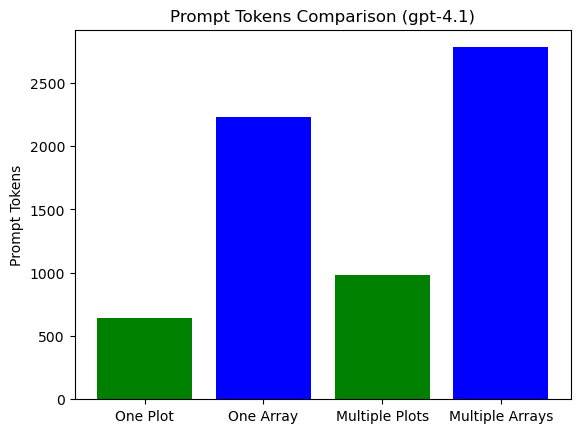

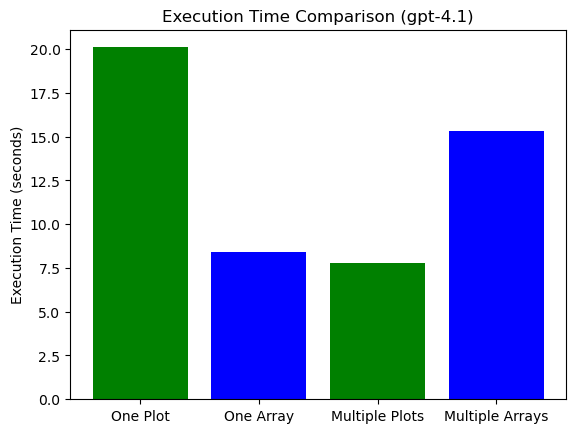

In [1]:
import matplotlib.pyplot as plt

labels = [
    "One Plot",
    "One Array",
    "Multiple Plots",
    "Multiple Arrays"
]

prompt_tokens = [640, 2231, 980, 2780]
execution_time = [20.1, 8.4, 7.8, 15.3]

colors = ['green', 'blue']

# Prompt Tokens Plot
plt.figure()
plt.bar(labels, prompt_tokens, color=colors)
plt.ylabel("Prompt Tokens")
plt.title("Prompt Tokens Comparison (gpt-4.1)")
plt.show()

# Execution Time Plot
plt.figure()
plt.bar(labels, execution_time, color=colors)
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison (gpt-4.1)")
plt.show()